<a href="https://colab.research.google.com/github/Mr-Tuigor/Salary-Prediction/blob/main/Streamlit_first_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd

In [52]:
df = pd.read_csv("/content/Salary_Data.csv")

## Load Data and Initial Inspection

This section loads the salary dataset and performs an initial inspection to understand its structure and basic statistics.

In [53]:
# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

# Display the last 5 rows of the DataFrame
print("\nLast 5 rows of the DataFrame:")
display(df.tail())

First 5 rows of the DataFrame:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0



Last 5 rows of the DataFrame:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0
6703,26.0,Female,High School,Sales Executive,1.0,35000.0


In [54]:
# Print a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [55]:
# Generate descriptive statistics of the DataFrame's numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


## Handle Missing Values

This section focuses on handling missing values in the dataset. Numerical columns will be imputed with their mean, and categorical columns with their mode, to ensure data completeness for modeling.

In [56]:
# Display the sum of null values for all columns
print("Current Missing Values Before Imputation:")
print(df.isnull().sum())

Current Missing Values Before Imputation:
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [57]:
# Impute missing values for numerical columns ('Age', 'Years of Experience', 'Salary') with their mean
# Using direct assignment to avoid FutureWarning with inplace=True
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())

print("\nMissing values after imputation for numerical columns:")
print(df[['Age', 'Years of Experience', 'Salary']].isnull().sum())


Missing values after imputation for numerical columns:
Age                    0
Years of Experience    0
Salary                 0
dtype: int64


In [58]:
# Impute missing values for categorical columns ('Gender', 'Education Level', 'Job Title') with their mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])

print("\nMissing values after imputation for all columns:")
print(df.isnull().sum())


Missing values after imputation for all columns:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


## Standardize and Encode Categorical Features

This section refactors the categorical feature preprocessing by standardizing 'Education Level' entries and then performing one-hot encoding for 'Gender', 'Education Level', and 'Job Title'.

### Standardize 'Education Level'

Before encoding, it's crucial to standardize entries in categorical columns to ensure consistency. The 'Education Level' column contains inconsistent values like "Bachelor's" and "Bachelor's Degree", as well as "phD" and "PhD". Standardizing these ensures that unique categories are correctly identified and processed during one-hot encoding, preventing redundant or incorrect feature creation.

In [59]:
# Standardize 'Education Level' entries
df['Education Level'] = df['Education Level'].replace({
    "Bachelor's": "Bachelor's Degree",
    "Master's": "Master's Degree",
    "phD": "PhD"
})

print("Updated 'Education Level' value counts after standardization:")
print(df['Education Level'].value_counts())

Updated 'Education Level' value counts after standardization:
Education Level
Bachelor's Degree    3026
Master's Degree      1861
PhD                  1369
High School           448
Name: count, dtype: int64


### One-Hot Encode Categorical Features

Apply one-hot encoding to the 'Gender', 'Education Level', and 'Job Title' columns. This will convert these categorical features into a numerical format suitable for machine learning models. The original categorical columns will be dropped after encoding.

In [60]:
# Apply one-hot encoding to categorical columns
df = pd.get_dummies(df, columns=['Gender', 'Education Level', 'Job Title'], drop_first=False)

print("DataFrame after one-hot encoding:")
display(df.head())

DataFrame after one-hot encoding:


,Age,Years of Experience,Salary,Gender_Female,Gender_Male,Gender_Other,Education Level_Bachelor's Degree,Education Level_High School,Education Level_Master's Degree,Education Level_PhD,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,5.0,90000.0,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,28.0,3.0,65000.0,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,15.0,150000.0,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,36.0,7.0,60000.0,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,52.0,20.0,200000.0,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


## Prepare Data for Modeling

This section separates the features (X) from the target variable (y - 'Salary') and then splits the dataset into training and testing sets. This is a crucial step before training any machine learning model, as it allows for an unbiased evaluation of the model's performance on unseen data.

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Salary', axis=1)
y = df['Salary']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (5363, 202)
Shape of X_test: (1341, 202)
Shape of y_train: (5363,)
Shape of y_test: (1341,)


## Model Selection and Training

This section initializes and trains various regression models, including Linear Regression, MLPRegressor (ANN), RandomForestRegressor, and GradientBoostingRegressor. Each model will be trained on the preprocessed training data.

### Train Linear Regression Model

We will start by training a simple Linear Regression model, which serves as a good baseline for comparison with more complex models.

In [62]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Train Additional Regression Models

We will now initialize and train the MLPRegressor, RandomForestRegressor, and GradientBoostingRegressor models. These models offer different approaches to regression and can provide a more comprehensive comparison of performance.

In [64]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Initialize MLPRegressor (ANN)
# Increased max_iter to prevent ConvergenceWarning for some datasets
mlp_model = MLPRegressor(random_state=42, max_iter=2000) # Increased max_iter to 2000

# Initialize RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)

# Initialize GradientBoostingRegressor
gbr_model = GradientBoostingRegressor(random_state=42)

# Initialize DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)

print("Models initialized. Now training...")

# Train MLPRegressor
print("\nTraining MLPRegressor...")
mlp_model.fit(X_train, y_train)
print("MLPRegressor trained successfully.")

# Train RandomForestRegressor
print("\nTraining RandomForestRegressor...")
rf_model.fit(X_train, y_train)
print("RandomForestRegressor trained successfully.")

# Train GradientBoostingRegressor
print("\nTraining GradientBoostingRegressor...")
gbr_model.fit(X_train, y_train)
print("GradientBoostingRegressor trained successfully.")

# Train DecisionTreeRegressor
print("\nTraining DecisionTreeRegressor...")
dt_model.fit(X_train, y_train)
print("DecisionTreeRegressor trained successfully.")

Models initialized. Now training...

Training MLPRegressor...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor trained successfully.

Training RandomForestRegressor...
RandomForestRegressor trained successfully.

Training GradientBoostingRegressor...
GradientBoostingRegressor trained successfully.

Training DecisionTreeRegressor...
DecisionTreeRegressor trained successfully.


## Model Evaluation

This section evaluates the performance of the trained models using various regression metrics (MAE, MSE, RMSE, R2). Predictions are made on the test set (`X_test`), and the results are compiled into a DataFrame for comparison.

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def get_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

metrics_data = []

# Linear Regression Metrics
y_pred_lr = linear_model.predict(X_test)
metrics_data.append(get_metrics("Linear Regression", y_test, y_pred_lr))

# MLPRegressor Metrics
y_pred_mlp = mlp_model.predict(X_test)
metrics_data.append(get_metrics("MLPRegressor", y_test, y_pred_mlp))

# RandomForestRegressor Metrics
y_pred_rf = rf_model.predict(X_test)
metrics_data.append(get_metrics("RandomForestRegressor", y_test, y_pred_rf))

# GradientBoostingRegressor Metrics
y_pred_gbr = gbr_model.predict(X_test)
metrics_data.append(get_metrics("GradientBoostingRegressor", y_test, y_pred_gbr))

# DecisionTreeRegressor Metrics
y_pred_dt = dt_model.predict(X_test)
metrics_data.append(get_metrics("DecisionTreeRegressor", y_test, y_pred_dt))

# Create DataFrame of metrics
metrics_df = pd.DataFrame(metrics_data)

print("Model Evaluation Metrics:")
display(metrics_df)

Model Evaluation Metrics:


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,15176.979360,4.375707e+08,20918.189814,0.836158
1,MLPRegressor,13693.753380,3.647361e+08,19098.065928,0.863430
2,RandomForestRegressor,3389.252944,7.893829e+07,8884.722491,0.970443
3,GradientBoostingRegressor,11587.549470,2.423515e+08,15567.641521,0.909255
4,DecisionTreeRegressor,3210.824590,9.299563e+07,9643.423948,0.965179


## Model Comparison and Visualization

This section compares the performance of all trained models based on their evaluation metrics. Visualizations will be used to highlight the strengths and weaknesses of each model, helping to identify the best-performing one for the salary prediction task.

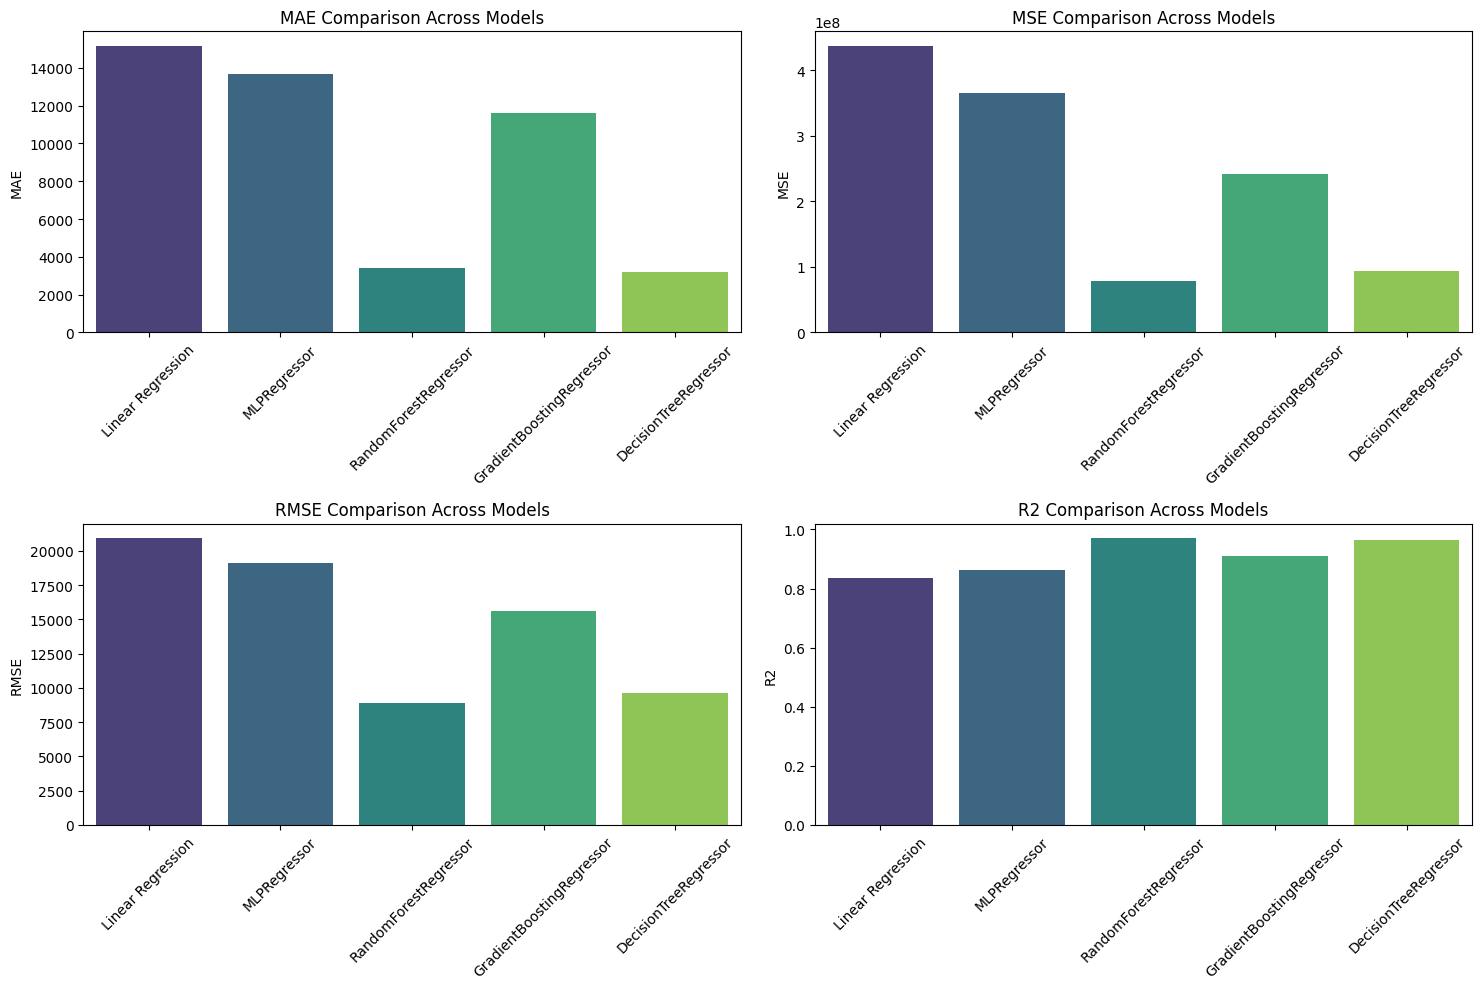

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Define the metrics to plot
metrics_to_plot = ['MAE', 'MSE', 'RMSE', 'R2']

# Create subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Model', y='Score', data=metrics_melted[metrics_melted['Metric'] == metric], ax=axes[i], palette='viridis', hue='Model', legend=False)
    axes[i].set_title(f'{metric} Comparison Across Models')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

## Identify and Save the Best Model

Based on the evaluation metrics, we identify the best performing model (RandomForestRegressor) and save it to a `.pkl` file for future use.

In [69]:
import joblib

# Identify the best performing model based on R2 score
best_model_name = metrics_df.loc[metrics_df['R2'].idxmax()]['Model']

if best_model_name == 'Linear Regression':
    best_model = linear_model
elif best_model_name == 'MLPRegressor':
    best_model = mlp_model
elif best_model_name == 'RandomForestRegressor':
    best_model = rf_model
elif best_model_name == 'GradientBoostingRegressor':
    best_model = gbr_model
elif best_model_name == 'DecisionTreeRegressor':
    best_model = dt_model
else:
    print("No best model found.")


# Define the filename for the best model
model_filename = 'best_salary_prediction_model.pkl'

# Save the best model to a .pkl file
joblib.dump(best_model, model_filename)

print(f"The best model, {best_model_name}, has been saved to {model_filename}")

The best model, RandomForestRegressor, has been saved to best_salary_prediction_model.pkl


## Prediction on New Data

This section demonstrates how to use the saved best model to predict salaries for new, unseen employee data. It involves preparing the new data in the same format as the training data and then applying the trained model for prediction.

In [72]:
import pandas as pd
import numpy as np

# Get the first 3 rows from the already preprocessed DataFrame for prediction
new_employee_data = df.head(3).copy()

# Store actual salaries for comparison
actual_salaries = new_employee_data['Salary']

# Drop the 'Salary' column from new_employee_data as it's the target variable
new_employee_features = new_employee_data.drop(columns=['Salary'])

# Align columns with the training data (X_train.columns)
new_employee_aligned = new_employee_features.reindex(columns=X_train.columns, fill_value=0)

# List of all trained models
all_models = {
    "Linear Regression": linear_model,
    "MLPRegressor": mlp_model,
    "RandomForestRegressor": rf_model,
    "GradientBoostingRegressor": gbr_model,
    "DecisionTreeRegressor": dt_model
}

all_predictions_results = []

for model_name, model_obj in all_models.items():
    predicted_salaries = model_obj.predict(new_employee_aligned)

    # For each prediction, create a row in the results
    for i in range(len(actual_salaries)):
        actual = actual_salaries.iloc[i]
        predicted = predicted_salaries[i]
        absolute_error = np.abs(actual - predicted)
        percentage_error = (absolute_error / actual) * 100 if actual != 0 else 0

        all_predictions_results.append({
            'Model': model_name,
            'Sample Index': i,
            'Actual Salary': actual,
            'Predicted Salary': predicted,
            'Absolute Error': absolute_error,
            'Percentage Error': percentage_error
        })

# Create a DataFrame from the collected results
full_prediction_results_df = pd.DataFrame(all_predictions_results)

print("Predictions for the first 3 rows across all models:")
display(full_prediction_results_df)

Predictions for the first 3 rows across all models:


,Model,Sample Index,Actual Salary,Predicted Salary,Absolute Error,Percentage Error
0,Linear Regression,0,90000.0,117126.505038,27126.505038,30.140561
1,Linear Regression,1,65000.0,121011.674812,56011.674812,86.171807
2,Linear Regression,2,150000.0,148156.735370,1843.264630,1.228843
3,MLPRegressor,0,90000.0,118764.963854,28764.963854,31.961071
4,MLPRegressor,1,65000.0,114072.727196,49072.727196,75.496503
5,MLPRegressor,2,150000.0,158950.109871,8950.109871,5.966740
6,RandomForestRegressor,0,90000.0,86100.000000,3900.000000,4.333333
7,RandomForestRegressor,1,65000.0,88776.318126,23776.318126,36.578951
8,RandomForestRegressor,2,150000.0,156400.000000,6400.000000,4.266667
9,GradientBoostingRegressor,0,90000.0,121362.174166,31362.174166,34.846860


In [67]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelComparison'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "ModelComparison", "ModelSaving", "Prediction"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

### 1. Install Streamlit

First, you need to install the Streamlit library. This will be done in a separate cell.

In [74]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 118.5 MB/s eta 0:00:00


### 2. Prepare the Model and Column Order for Deployment

To ensure the Streamlit app uses the correct feature order and values for one-hot encoding, we need to save the `X_train` columns and the best model. We've already saved the best model, so now we'll save the column order.

In [75]:
import joblib

# Save the column order of X_train
joblib.dump(X_train.columns, 'X_train_columns.pkl')
print("X_train_columns.pkl saved successfully!")

X_train_columns.pkl saved successfully!


### 3. Create the Streamlit Application File

Now, we'll create a Python file (`app.py`) that will contain your Streamlit application code. This code will load your saved model, create input widgets for features, and display the prediction. Due to the large number of job titles, only a few sample job titles are included in the dropdown for demonstration. You can expand this list with all unique job titles from your original dataset.

Since this file is typically run from the command line, we'll write its content to a file in Colab.

In [76]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the best model and column order
best_model = joblib.load('best_salary_prediction_model.pkl')
X_train_columns = joblib.load('X_train_columns.pkl')

st.title('Salary Prediction App')
st.write('Enter employee details to predict their salary.')

# Input widgets for user features
age = st.slider('Age', 18, 65, 30)
years_of_experience = st.slider('Years of Experience', 0.0, 40.0, 5.0)

gender = st.selectbox('Gender', ['Male', 'Female', 'Other'])
education_level = st.selectbox('Education Level', ['Bachelor\'s Degree', 'Master\'s Degree', 'PhD', 'High School'])

# For Job Title, we will create a selectbox with a few common titles.
# In a real application, you would populate this with all unique job titles from your training data.
job_title_options = [
    'Software Engineer',
    'Data Scientist',
    'Project Manager',
    'Marketing Analyst',
    'HR Manager',
    'Sales Representative',
    'Accountant',
    'Financial Analyst',
    'UX Designer',
    'Operations Manager',
    'IT Support Specialist',
    'Teacher'
]
job_title = st.selectbox('Job Title', job_title_options)

if st.button('Predict Salary'):
    # Create a DataFrame for the new input data
    input_data = pd.DataFrame({
        'Age': [age],
        'Years of Experience': [years_of_experience],
        'Gender': [gender],
        'Education Level': [education_level],
        'Job Title': [job_title]
    })

    # One-hot encode categorical features (mimic preprocessing during training)
    # Create a template DataFrame with all possible one-hot encoded columns from X_train_columns
    # This ensures consistency in column order and presence
    processed_input = pd.DataFrame(0, index=[0], columns=X_train_columns)

    # Fill in numerical features
    processed_input['Age'] = age
    processed_input['Years of Experience'] = years_of_experience

    # Fill in one-hot encoded categorical features
    gender_col = f'Gender_{gender}'
    if gender_col in processed_input.columns: # Check if column exists, as 'Other' might not always be present if not in training data
        processed_input[gender_col] = 1

    education_col = f'Education Level_{education_level}'
    if education_col in processed_input.columns:
        processed_input[education_col] = 1

    job_title_col = f'Job Title_{job_title}'
    if job_title_col in processed_input.columns:
        processed_input[job_title_col] = 1

    # Make prediction
    predicted_salary = best_model.predict(processed_input)[0]

    st.success(f'Predicted Salary: ${predicted_salary:,.2f}')


Writing app.py
